# Análise Preditiva de Logística - Prever Números de Passageiros em uma linha

## Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Carregando Dataset

In [2]:
df = pd.read_csv("084.csv", sep=";", encoding="ISO-8859-1")

In [3]:
display(df.head())

,Ano,Mês,Situação da Empresa,Tipo da Empresa,Razão Social,ID da Linha,Prefixo,Serviço,Ambito Secao,Código Município IBGE Origem,...,Quantidade Gratuidades Passe Livre Ida,Quantidade Desconto Idosos Ida,Quantidade Pagantes Ida,Quantidade Gratuidades Jovens com Desconto Volta,Quantidade Gratuidades Jovens Volta,Quantidade Gratuidades Idosos Volta,Quantidade Gratuidades Passe Livre Volta,Quantidade Desconto Idosos Volta,Quantidade Pagantes Volta,Km
0,2016,4,ativa ...,nacional ...,MATRIZ TRANSPORTES LTDA ...,10119,15943000,RODOVIARIO ...,INTERESTADUAL ...,5201108,...,0,0,0,0,0,0,0,0,0,"0,0"
1,2016,8,ativa ...,nacional ...,MATRIZ TRANSPORTES LTDA ...,12140,15900000,RODOVIARIO ...,INTERESTADUAL ...,5201108,...,0,0,0,0,0,0,0,0,0,"0,0"
2,2016,1,ativa ...,nacional ...,MATRIZ TRANSPORTES LTDA ...,10119,15943000,RODOVIARIO ...,INTERESTADUAL ...,5201108,...,0,0,0,0,0,0,0,0,0,"0,0"
3,2016,8,ativa ...,nacional ...,MATRIZ TRANSPORTES LTDA ...,10119,15943000,RODOVIARIO ...,INTERESTADUAL ...,5201108,...,0,0,0,0,0,0,0,0,0,"0,0"
4,2016,4,ativa ...,nacional ...,MATRIZ TRANSPORTES LTDA ...,12140,15900000,RODOVIARIO ...,INTERESTADUAL ...,5201108,...,0,0,0,0,0,0,0,0,0,"0,0"


In [4]:
len(df)

9097845

# Limpeza

### Dropando Dados e Colunas Desnecessárias

In [5]:
# Colunas desnecessárias
columns_to_drop = ["Quantidade Gratuidades Jovens com Desconto Volta", "Quantidade Gratuidades Jovens Volta", "Quantidade Gratuidades Idosos Volta", "Quantidade Gratuidades Passe Livre Volta", "Quantidade Desconto Idosos Volta", "Quantidade Desconto Idosos Ida", "Quantidade Gratuidades Passe Livre Ida", "Quantidade Gratuidades Idosos Ida", "Quantidade Gratuidades Jovens Ida", "Quantidade Gratuidades Jovens com Desconto Ida"]

In [6]:
df.drop(columns_to_drop, axis=1, inplace=True)

### Deixando apenas dados dos últimos 3 anos

In [7]:
df['Ano'].value_counts()

Ano
2021    1203924
2016     939214
2022     879865
2018     809463
2019     782240
2020     775504
2017     774253
2013     744663
2015     734702
2014     694350
2023     392375
1900     367292
Name: count, dtype: int64

In [8]:
# Lista com todos os anos
anos = [2021,2022,2023]

In [9]:
df = df[df['Ano'].isin(anos)]

In [10]:
len(df)

2476164

### Renomeando Colunas

In [11]:
new_columns = ['ano', 'mes', 'situacao_empresa', 'tipo_empresa', 'razao_social', 'id_linha', 'prefixo', 'servico', 'ambito_secao', 'cod_municipio_ibge_origem', 'id_origem',
'origem', 'uf_origem', 'id_localidade_origem', 'localidade_origem', 'codigo_municipio_ibge_destino', 'id_destino', 'destino', 'uf_destino', 'id_localidade_destino', 'localidade_destino',
'qtd_lugares_ofertados_ida', 'qtd_lugares_ofertados_volta', 'qtd_viagens_ida', 'qtd_viagens_volta', 'qtd_pagantes_ida', 'qtd_pagantes_volta', 'km']

In [12]:
old_columns = ['Ano', 'Mês', 'Situação da Empresa', 'Tipo da Empresa', 'Razão Social', 'ID da Linha', 'Prefixo', 'Serviço', 'Ambito Secao', 'Código Município IBGE Origem', 'ID Município Origem',
'Município Origem', 'UF Origem', 'ID Localidade Origem', 'Localidade Origem', 'Código Município IBGE Destino', 'ID Município Destino', 'Município Destino', 'UF Destino', 'ID Localidade Destino',
'Localidade Destino', 'Quantidade Lugares Ofertados Ida', 'Quantidade Lugares Ofertados Volta', 'Quantidade Viagens Ida', 'Quantidade Viagens Volta', 'Quantidade Pagantes Ida','Quantidade Pagantes Volta',
'Km']

In [13]:
columns_map = dict(zip(old_columns, new_columns))

In [14]:
df.rename(columns=columns_map, inplace=True)

In [15]:
df.head()

,ano,mes,situacao_empresa,tipo_empresa,razao_social,id_linha,prefixo,servico,ambito_secao,cod_municipio_ibge_origem,...,uf_destino,id_localidade_destino,localidade_destino,qtd_lugares_ofertados_ida,qtd_lugares_ofertados_volta,qtd_viagens_ida,qtd_viagens_volta,qtd_pagantes_ida,qtd_pagantes_volta,km
280,2021,4,ativa ...,nacional ...,SOLIMOES TRANSPORTES DE PASSAGEIROS E CARGAS L...,14709,11003400,RODOVIARIO ...,INTERESTADUAL ...,5106752,...,AC,62,RIO BRANCO ...,0,0,0,0,0,0,"151460,0"
282,2021,4,ativa ...,nacional ...,SOLIMOES TRANSPORTES DE PASSAGEIROS E CARGAS L...,14679,9026400,RODOVIARIO ...,INTERESTADUAL ...,5106752,...,AC,62,RIO BRANCO ...,0,0,0,0,0,0,"152890,0"
285,2023,6,ativa ...,nacional ...,SOLIMOES TRANSPORTES DE PASSAGEIROS E CARGAS L...,16991,9026461,RODOVIARIO ...,INTERESTADUAL ...,5106752,...,AC,62,RIO BRANCO ...,0,0,0,0,5,7,"1528,9"
286,2023,8,ativa ...,nacional ...,SOLIMOES TRANSPORTES DE PASSAGEIROS E CARGAS L...,31936,9026431,RODOVIARIO ...,INTERESTADUAL ...,5106752,...,AC,62,RIO BRANCO ...,0,0,0,0,0,2,"1528,9"
289,2021,8,ativa ...,nacional ...,SOLIMOES TRANSPORTES DE PASSAGEIROS E CARGAS L...,14679,9026400,RODOVIARIO ...,INTERESTADUAL ...,5106752,...,AC,62,RIO BRANCO ...,0,0,0,0,0,0,"152890,0"


### Verificando os tipos das colunas

In [16]:
df.dtypes

ano                               int64
mes                               int64
situacao_empresa                 object
tipo_empresa                     object
razao_social                     object
id_linha                          int64
prefixo                           int64
servico                          object
ambito_secao                     object
cod_municipio_ibge_origem         int64
id_origem                         int64
origem                           object
uf_origem                        object
id_localidade_origem              int64
localidade_origem                object
codigo_municipio_ibge_destino     int64
id_destino                        int64
destino                          object
uf_destino                       object
id_localidade_destino             int64
localidade_destino               object
qtd_lugares_ofertados_ida         int64
qtd_lugares_ofertados_volta       int64
qtd_viagens_ida                   int64
qtd_viagens_volta                 int64


In [64]:
display(df['razao_social'].nunique())

194

In [60]:
display(df['servico'].value_counts())

servico
RODOVIARIO                                                                                              2471763
SEMI-URBANO                                                                                                1123
SEMI-URBANO LOTE 4                                                                                          336
Name: count, dtype: int64

### Removendo destinos e origem internacionais

In [17]:
df = df[~df['uf_destino'].isin(['PRY                 ', 'URY                 ', 'VEN                 '])]

In [18]:
df = df[~df['uf_origem'].isin(['BOL'])]

### Utilizando o Label Encoder para categorizar a coluna

In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['uf_origem_encoded'] = le.fit_transform(df['uf_origem'])
df['uf_destino_encoded'] = le.transform(df['uf_destino'])

In [20]:
df.drop(columns=['uf_origem', 'uf_destino'], inplace=True)

### Removendo por conta de 99.99978 % das empresas serem nacionais e o restante internacional

In [21]:
df.drop(columns='tipo_empresa', inplace=True)

## Dropando colunas com alta dimensionalidade

In [22]:
df.drop(columns=['id_localidade_destino', 'id_destino', 'destino', 'origem', 'localidade_origem', 'localidade_destino', 'id_localidade_origem'], inplace=True)

## Alterando o tipo das colunas

In [23]:
df['km'] = df['km'].str.replace(',', '.').astype(float)

In [24]:
df['situacao_empresa'] = df['situacao_empresa'].map({"ativa": 1, "inativa": 0})

In [25]:
df['is_interestadual'] = df['ambito_secao'].map({"interestadual": 1, "internacional": 0})
df.drop(columns='ambito_secao', inplace=True)

In [26]:
df['is_rodoviario'] = df['servico'].map({"RODOVIARIO": 1, 'SEMI_URBANO': 0, 'SEMI-URBANO LOTE 4' : 0})
df.drop(columns='servico', inplace=True)

# Feature Engineering

In [27]:
df['total_viagens'] = df['qtd_viagens_ida'] + df['qtd_viagens_volta']

empresa_rank = df.groupby('razao_social')['total_viagens'].sum().rank(method='dense', ascending=False)
df['empresa_rank'] = df['razao_social'].map(empresa_rank)

In [28]:
df['empresa_rank'].nunique()

163

In [29]:
df['empresa_encoded'] = df.groupby('razao_social')['total_viagens'].transform('mean')

In [30]:
df['mesmo_estado'] = (df['uf_origem_encoded'] == df['uf_destino_encoded']).astype(int)

In [31]:
df['estacao'] = df['mes'].map({
    12: 'Verão', 1: 'Verão', 2: 'Verão',
    3: 'Outono', 4: 'Outono', 5: 'Outono',
    6: 'Inverno', 7: 'Inverno', 8: 'Inverno',
    9: 'Primavera', 10: 'Primavera', 11: 'Primavera'
})

## Salvando Dataset Final

In [ ]:
df.to_csv("df_final.csv", index=False)

# Análise

### Features do Modelo
Ano, Mês, UF Origem, UF Destino, Km,
Situação da Empresa, Tipo da Empresa.

### Targets
Quantidade Viagens Ida

In [73]:
df.columns

Index(['ano', 'mes', 'situacao_empresa', 'tipo_empresa', 'razao_social',
       'id_linha', 'prefixo', 'servico', 'ambito_secao',
       'cod_municipio_ibge_origem', 'id_origem', 'origem', 'uf_origem',
       'id_localidade_origem', 'localidade_origem',
       'codigo_municipio_ibge_destino', 'id_destino', 'destino', 'uf_destino',
       'id_localidade_destino', 'localidade_destino',
       'qtd_lugares_ofertados_ida', 'qtd_lugares_ofertados_volta',
       'qtd_viagens_ida', 'qtd_viagens_volta', 'qtd_pagantes_ida',
       'qtd_pagantes_volta', 'km'],
      dtype='object')

### Sampleando o Dataset para fazer análise estatísticas

In [22]:
df_sampled = df.sample(frac=0.05, random_state=42)

In [23]:
len(df_sampled)

123808

In [24]:
# Transformando o tipo da coluna de String para Double
df_sampled['km'] = df_sampled['km'].str.replace(',', '.').astype('double')

In [26]:
df_sampled['km_1'] = df_sampled['km'].where(df_sampled['km'] < 50000)
df_sampled['km_2'] = df_sampled['km'].where(df_sampled['km'] < 1000)
df_sampled['qtd_viagens_ida'] = df_sampled['qtd_viagens_ida'].where(df_sampled['qtd_viagens_ida'] < 1000)

In [27]:
# Fazendo um agrupamento
df_sampled['kms_agrupados'] = pd.cut(df_sampled['km'], bins=[0, 10, 25, 50, 100, 500, 1000, 5000, 10000, 20000, 50000, 100000], labels=['0-10', '10-25', '25-50', '50-100', '100-500', '500-1k', '1k-5k', '5k-10k', '10k-20k', '20k-50k', '50k-100k'])

### Relação entre Distância e Demanda

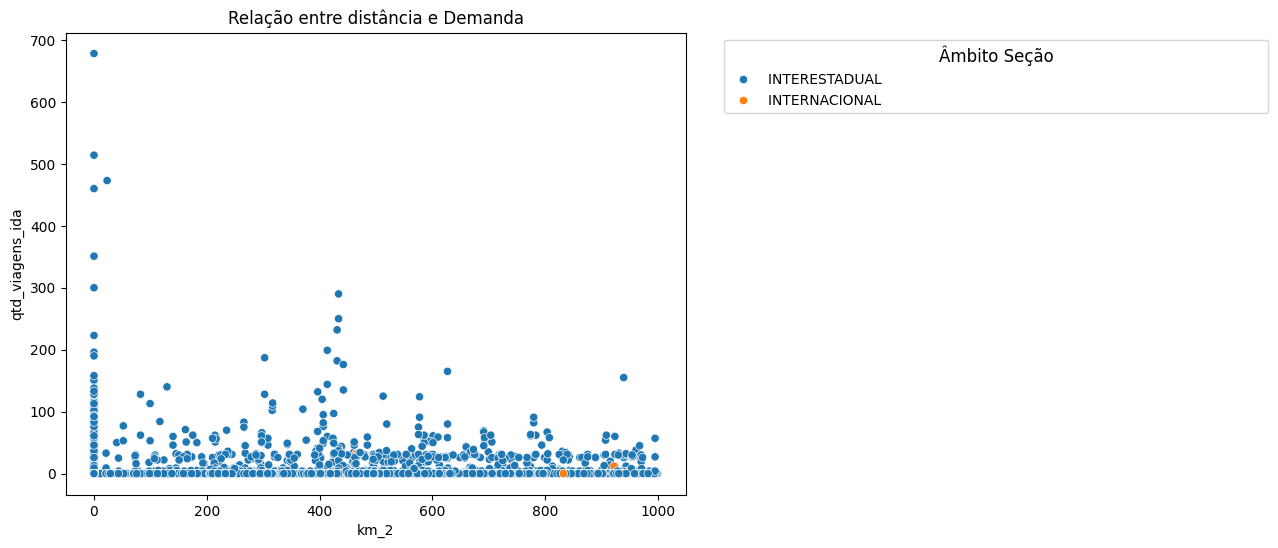

In [28]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_sampled, x="km_2", y="qtd_viagens_ida", hue="ambito_secao")
plt.title('Relação entre distância e Demanda')
plt.legend(title="Âmbito Seção", fontsize=10, title_fontsize=12, loc='upper left', bbox_to_anchor=(1.05, 1))
plt.show()

## Série Temporal da Quantidade de Viagens

In [29]:
# Criar a coluna data (datetime)
df_sampled['data'] = pd.to_datetime(df['ano'].astype(str) + "-" + df['mes'].astype(str) + "-01")

In [30]:
# Agrupando os dados pela coluna data
df_agg = df_sampled.groupby("data")[["qtd_viagens_ida", "qtd_viagens_volta"]].sum()

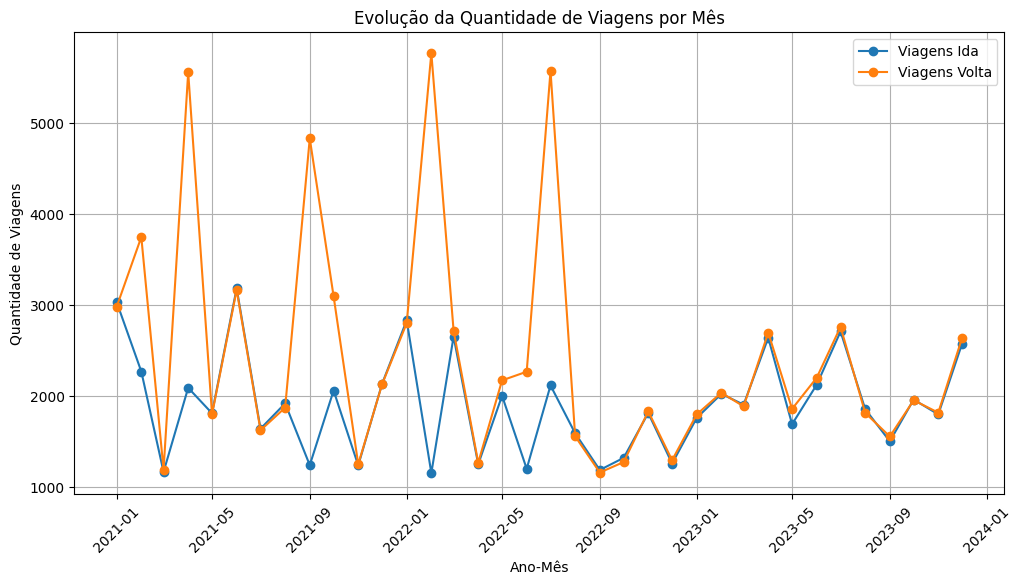

In [31]:
plt.figure(figsize=(12,6))
plt.plot(df_agg.index, df_agg["qtd_viagens_ida"], marker="o", label="Viagens Ida")
plt.plot(df_agg.index, df_agg["qtd_viagens_volta"], marker="o", label="Viagens Volta")
plt.xlabel("Ano-Mês")
plt.ylabel("Quantidade de Viagens")
plt.title("Evolução da Quantidade de Viagens por Mês")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

## Gráfico de Barras de viagens por Origem e Destino

In [33]:
df_agg_origem = df_sampled.groupby('uf_origem')['qtd_viagens_ida'].sum().reset_index()
df_agg_destino = df_sampled.groupby('uf_destino')['qtd_viagens_volta'].sum().reset_index()

C:\Users\Guilherme\AppData\Local\Temp\ipykernel_2232\1166021552.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="uf_origem", y="qtd_viagens_ida", data=df_agg_origem, ax=ax[0], palette="Blues")
C:\Users\Guilherme\AppData\Local\Temp\ipykernel_2232\1166021552.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="uf_destino", y="qtd_viagens_volta", data=df_agg_destino, ax=ax[1], palette="Oranges")


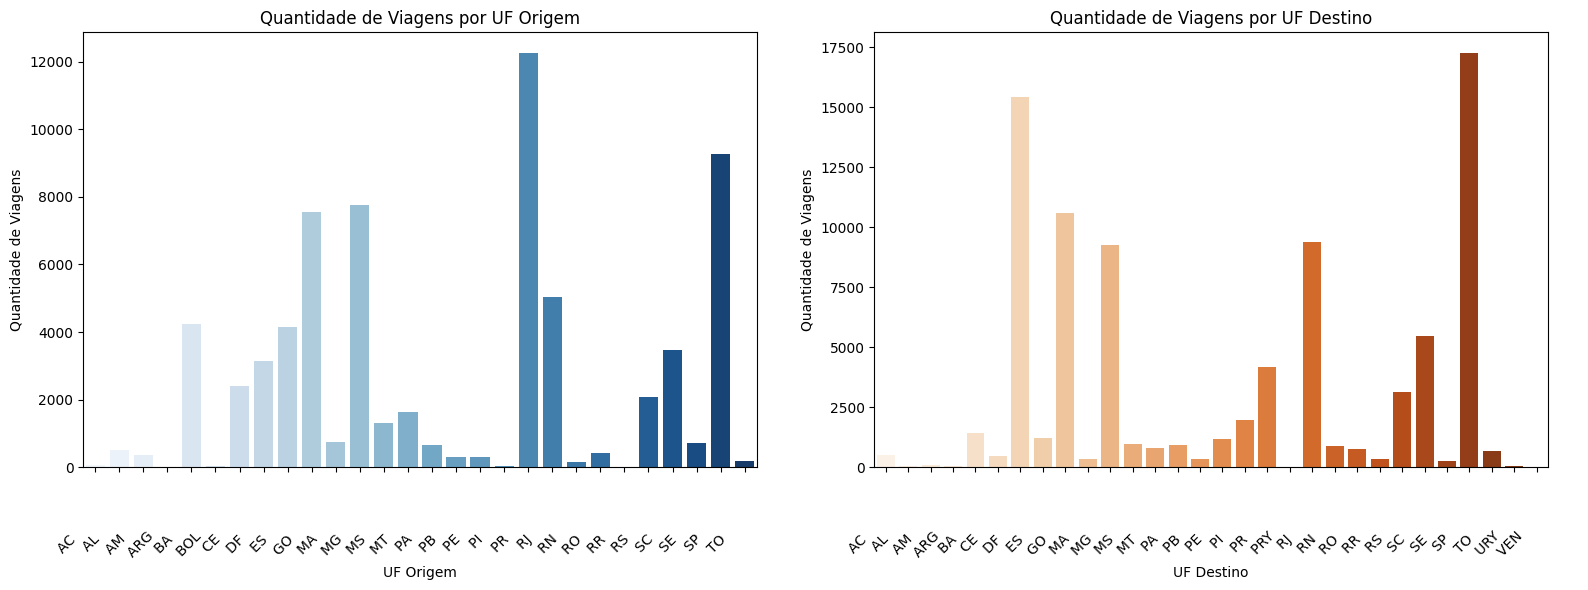

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(16,6))
sns.barplot(x="uf_origem", y="qtd_viagens_ida", data=df_agg_origem, ax=ax[0], palette="Blues")
ax[0].set_title("Quantidade de Viagens por UF Origem")
ax[0].set_xlabel("UF Origem")
ax[0].set_ylabel("Quantidade de Viagens")
ax[0].tick_params(axis='x', rotation=45)

sns.barplot(x="uf_destino", y="qtd_viagens_volta", data=df_agg_destino, ax=ax[1], palette="Oranges")
ax[1].set_title("Quantidade de Viagens por UF Destino")
ax[1].set_xlabel("UF Destino")
ax[1].set_ylabel("Quantidade de Viagens")
ax[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Correlação

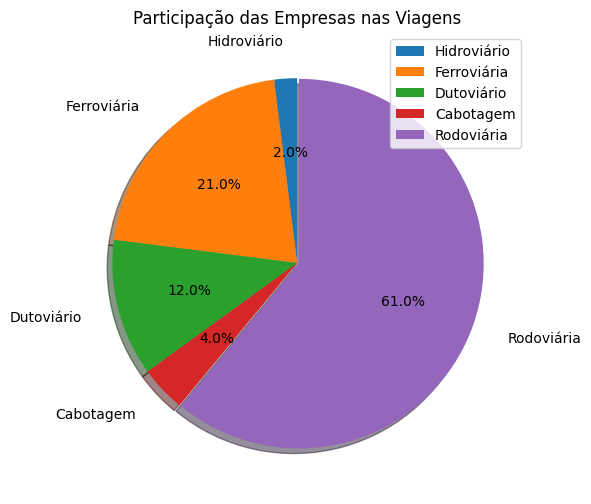

In [98]:
import matplotlib.pyplot as plt
labels = ['Hidroviário', 'Ferroviária', 'Dutoviário', 'Cabotagem', 'Rodoviária']
valores = [2, 21, 12, 4, 61]

plt.figure(figsize=(6,6))
plt.pie(valores, labels=labels, autopct='%1.1f%%', startangle=90,
        explode=[0, 0, 0, 0, .01], shadow=True, labeldistance=1.2)
plt.title('Participação das Empresas nas Viagens')
plt.legend()
# plt.axis('equal')
plt.show()

In [44]:
correlacoes = df_sampled.corr()
print(correlacoes)

ValueError: could not convert string to float: 'ativa                                                                                               '